<a href="https://colab.research.google.com/github/mannatdhull124/Bank-Term-Deposit-Subscription-Prediction/blob/main/my_logistic_regression_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Problem Statement

The objective of this project is to predict whether a bank customer will subscribe to a term deposit using Logistic Regression.

The dataset contains customer information such as age, job type, marital status, education level, loan details, and previous marketing interactions. It also includes economic indicators like employment rate, consumer confidence index, and interest rates.

Marketing campaigns are costly, so it is important for banks to identify potential customers who are more likely to subscribe to term deposits.

The goal is to build a classification model that can accurately predict whether a client will subscribe to a term deposit (y = yes or no).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving bank-additional-full (3) (1) (2).csv to bank-additional-full (3) (1) (2) (1).csv


In [ ]:
df = pd.read_csv('/content/bank-additional-full (3) (1) (2).csv', sep=';')

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


age: Age of the costomer/client

job: Type of job

married: Marital status of the customer

education: Education level

default: The person has a history of default credit or loan(Bad credit).

housing: Has housing loan

loan: Has personal loan

contact: Contact communication type

month: Last contact month

day_of_week: Last contact of the week

duration: Last contact duration in seconds

campaign: Number of contacts performed during this campaign

pdays: Days since the client was last contacted(999 means never contacted before)

previous: Number of contacts before this campaign

poutcome: Outcome of the previous marketing campaign

emp.var.rate: Employment variation rate

cons.price.idx: Consumer price index, an indicator that measures average price changes for goods and services bought by households

cons.conf.idx: Consumer confidence index, it measures how confident/satisfied/optmistic people feel about the company.

euribor3m: Euribor 3month rate. It is the interest rate at which european banks lend money to each other for 3 months.

nr.employed: Number of employed people

y: Has the client subscribed/took the fixed deposit/term deposit.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41195.000000,41196.000000,41196.000000,41196.000000,41196.000000,41196.000000,41195.000000,41196.000000,41196.000000,41196.000000
mean,40.030319,258.281265,2.567676,962.482547,0.173124,0.081656,93.575867,-40.504600,3.620787,5166.996405
std,10.431818,259.254211,2.769751,186.893451,0.494987,1.570894,0.578999,4.629972,1.734655,72.300104
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
df.describe().T  #for transpose

,count,mean,std,min,25%,50%,75%,max
age,41195.0,40.030319,10.431818,17.000,32.000,38.000,47.000,98.000
duration,41196.0,258.281265,259.254211,0.000,102.000,180.000,319.000,4918.000
campaign,41196.0,2.567676,2.769751,1.000,1.000,2.000,3.000,56.000
pdays,41196.0,962.482547,186.893451,0.000,999.000,999.000,999.000,999.000
previous,41196.0,0.173124,0.494987,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41196.0,0.081656,1.570894,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41195.0,93.575867,0.578999,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41196.0,-40.504600,4.629972,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41196.0,3.620787,1.734655,0.634,1.344,4.857,4.961,5.045
nr.employed,41196.0,5166.996405,72.300104,4963.600,5099.100,5191.000,5228.100,5228.100


In [ ]:
df.describe(include='O').T

,count,unique,top,freq
job,41194,12,admin.,10422
marital,41194,4,married,24934
education,41194,8,university.degree,12168
default,41195,3,no,32595
housing,41196,3,yes,21584
loan,41195,3,no,33957
contact,41195,2,cellular,26151
month,41196,10,may,13769
day_of_week,41196,5,thu,8623
poutcome,41194,3,nonexistent,35563


**Data Cleaning**

Check for null values and deal with it accordingly. Check for duplicate data and print all the duplicate rows.

In [ ]:
df.isnull().sum()

,0
age,4
job,5
marital,5
education,5
default,4
housing,3
loan,4
contact,4
month,3
day_of_week,3


In [ ]:
df.isnull().sum().sum()

np.int64(76)

In [ ]:
df.dropna(inplace=True)    # drop the null values from dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41190 entries, 0 to 41194
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41190 non-null  float64
 1   job             41190 non-null  object 
 2   marital         41190 non-null  object 
 3   education       41190 non-null  object 
 4   default         41190 non-null  object 
 5   housing         41190 non-null  object 
 6   loan            41190 non-null  object 
 7   contact         41190 non-null  object 
 8   month           41190 non-null  object 
 9   day_of_week     41190 non-null  object 
 10  duration        41190 non-null  float64
 11  campaign        41190 non-null  float64
 12  pdays           41190 non-null  float64
 13  previous        41190 non-null  float64
 14  poutcome        41190 non-null  object 
 15  emp.var.rate    41190 non-null  float64
 16  cons.price.idx  41190 non-null  float64
 17  cons.conf.idx   41190 non-null  floa

In [ ]:
df.duplicated().sum()

np.int64(13)

In [ ]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39.0,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36.0,retired,married,unknown,no,no,no,telephone,jul,thu,...,1.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27.0,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47.0,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32.0,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55.0,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41.0,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39.0,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2.0,999.0,0.0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24.0,services,single,high.school,no,yes,no,cellular,apr,tue,...,1.0,999.0,0.0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35.0,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4.0,999.0,0.0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [ ]:
df.drop_duplicates(inplace=True)  #drop all the duplicate values from dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# check for outliers in this data, store all the columns with outliers in a list

import plotly.express as px

In [ ]:
for x in df.columns:
  if df[x].dtype!="object":
    figure=px.box(df,x=x,title=x)
    figure.update_layout(width=500,height=500)
    figure.show()

In [ ]:
out_list=['age','duration','campaign','cons.conf.idx']

In [ ]:
df[out_list]

,age,duration,campaign,cons.conf.idx
0,56.0,261.0,1.0,-36.4
1,57.0,149.0,1.0,-36.4
2,37.0,226.0,1.0,-36.4
3,40.0,151.0,1.0,-36.4
4,56.0,307.0,1.0,-36.4
...,...,...,...,...
41184,46.0,383.0,1.0,-50.8
41185,56.0,189.0,2.0,-50.8
41186,44.0,442.0,1.0,-50.8
41187,74.0,239.0,3.0,-50.8


In [ ]:
for x in out_list:
  Q1= df[x].quantile(0.25)
  Q3= df[x].quantile(0.75)
  IQR= Q3-Q1
  LB = Q1-1.5*IQR
  UB = Q3+1.5*IQR
  df = df[(df[x]>LB)& (df[x]<=UB)]

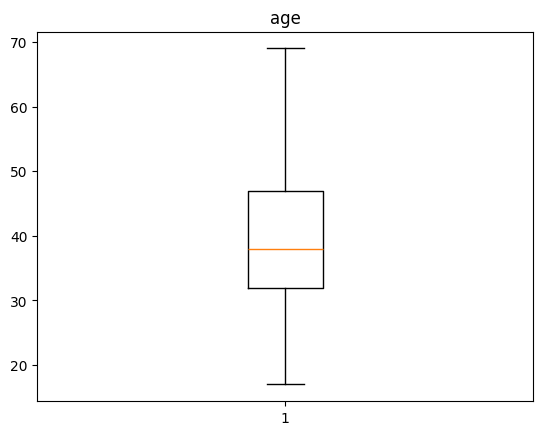

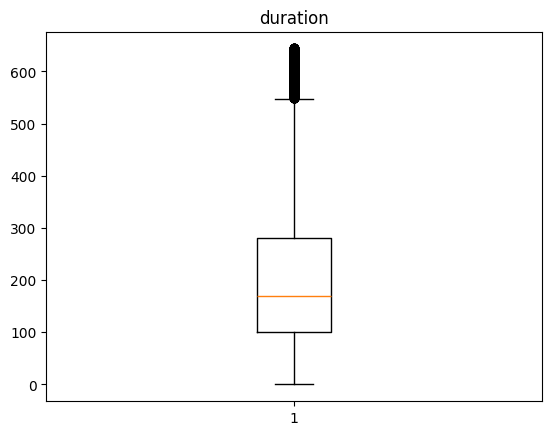

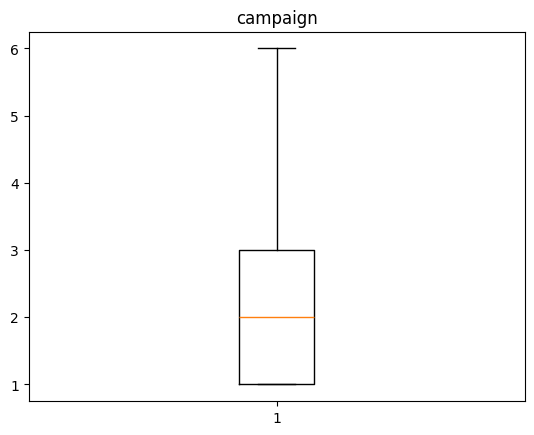

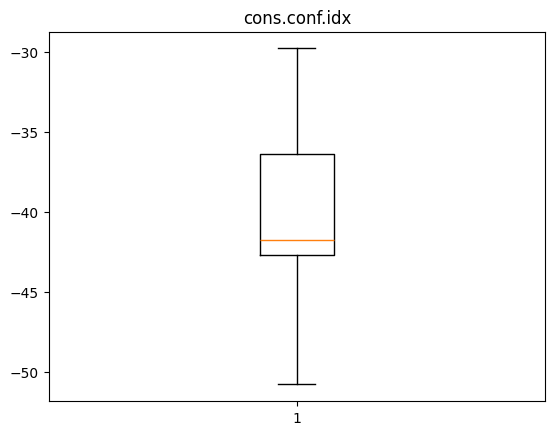

In [ ]:
for x in out_list:
  plt.boxplot(df[x])
  plt.title(x)
  plt.show()

# ⚙️ Solution Approach

To solve the bank marketing prediction problem, the following steps were performed:

1. Data Preprocessing:
   - Handled missing values
   - Converted categorical variables into numerical form using encoding techniques (One-Hot Encoding)
   - Cleaned and prepared dataset for modeling

2. Exploratory Data Analysis (EDA):
   - Used count plots and histograms to analyze feature distribution
   - Used boxplots to detect outliers
   - Observed relationships between features and target variable

3. Handling Class Imbalance:
   - Checked distribution of target variable
   - Applied techniques if necessary to balance the dataset

4. Feature Scaling:
   - Applied standardization to numerical features

5. Model Building:
   - Implemented Logistic Regression model
   - Logistic Regression estimates probability of a customer subscribing

6. Model Evaluation:
   - Evaluated using Accuracy Score, Confusion Matrix, and ROC Curve
   - Checked model performance on test data

7. Interpretation:
   - Analyzed model coefficients to understand feature impact
   - Identified important factors influencing subscription

In [ ]:
df = pd.get_dummies(df, drop_first=True) #Convert Object (Categorical) → Numeric

Defining  x and y

In [ ]:
print(df.columns)

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_s

In [ ]:
X = df.drop('y_yes', axis=1)
y = df['y_yes']

**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

**Train Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**Prediction**

In [ ]:
y_pred = model.predict(X_test)

**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9370112327598464
[[6373  148]
 [ 295  217]]
              precision    recall  f1-score   support

       False       0.96      0.98      0.97      6521
        True       0.59      0.42      0.49       512

    accuracy                           0.94      7033
   macro avg       0.78      0.70      0.73      7033
weighted avg       0.93      0.94      0.93      7033



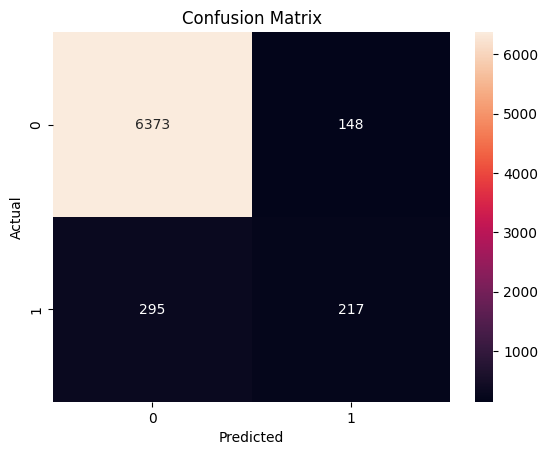

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

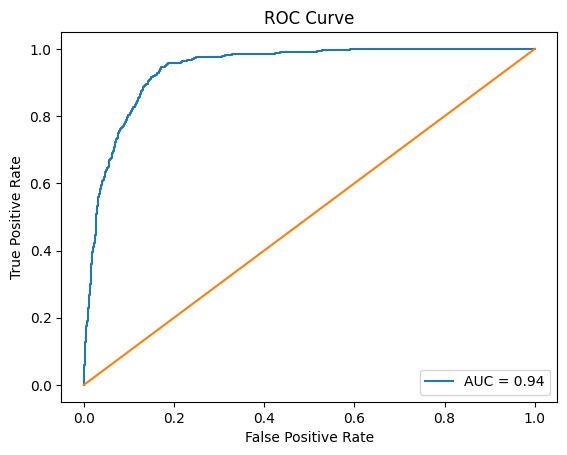

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

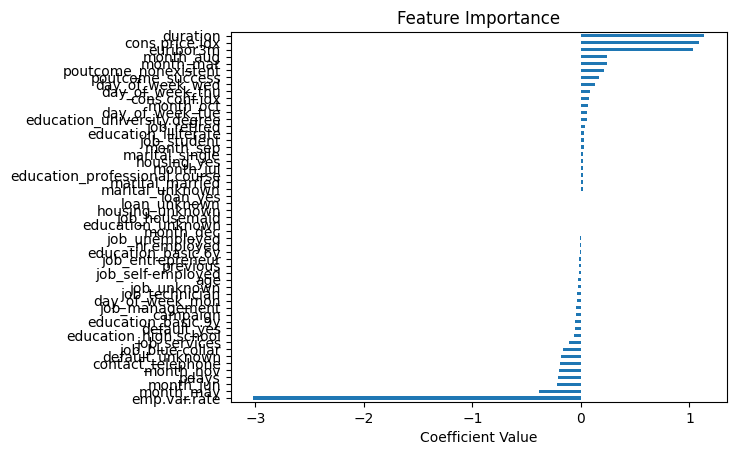

In [ ]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values()

plt.figure()
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()

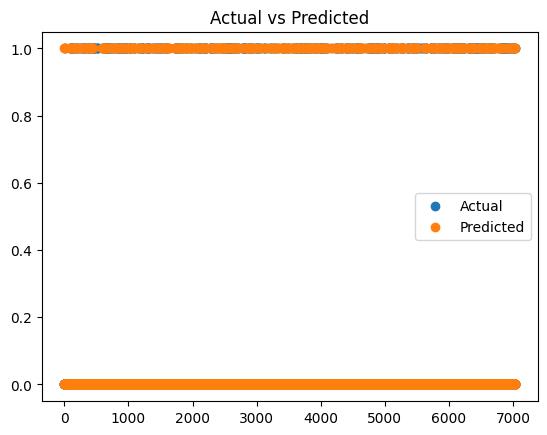

In [ ]:
plt.figure()
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# 📈 Results and Conclusion

The Logistic Regression model successfully predicted whether a customer would subscribe to a term deposit.

The model provided probabilistic outputs, making it useful for decision-making in marketing strategies.

Features such as duration, euribor3m, and previous campaign outcomes had a significant impact on predictions.

The model can help banks target the right customers, reduce marketing costs, and improve campaign efficiency.

Thus, Logistic Regression proves to be an effective and interpretable model for this classification problem.